<a href="https://colab.research.google.com/github/SSHIRONEKOO/realfill_apai3010_gp11/blob/main/eval_realfill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RealFill Model Evaluation

Based on [RealFill paper](https://arxiv.org/abs/2309.16668v2).
## Metrics

| Level | Metric | Direction |
|-------|--------|----------|
| Low   | PSNR   | higher = better |
|       | SSIM   | higher = better |
|       | LPIPS  | lower  = better |
| Mid   | DreamSim | lower  = better |
| High  | CLIP   | higher = better |
|       | DINO   | higher = better |

Low-level metrics computed inside filled region only. Mid/High on full image.


## 1. Install Dependencies

In [1]:
import subprocess, sys
REQUIRED = ['lpips', 'timm', 'torchvision', 'ftfy', 'scikit-image', 'diffusers', 'transformers', 'peft', 'dreamsim']
for pkg in REQUIRED:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print('[INSTALL]', pkg)
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('DONE: dependencies ready')

[INSTALL] lpips
[INSTALL] ftfy
[INSTALL] scikit-image
[INSTALL] dreamsim
DONE: dependencies ready


## 2. Configuration & Setup

In [2]:
import os, random, numpy as np
from pathlib import Path
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

# ==== EDIT THIS ====
EVAL_BASE_DIR = '/content/drive/MyDrive/Evaluation'
OUTPUT_DIR = './eval_output'
SEED = 42
# ===================

os.makedirs(OUTPUT_DIR, exist_ok=True)
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE} | Base Data Dir: {EVAL_BASE_DIR}')

Device: cuda | Base Data Dir: /content/drive/MyDrive/Evaluation


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# 更新数据路径
DATA_DIR = '/content/drive/MyDrive/Evaluation'
print(f'DATA_DIR updated to: {DATA_DIR}')

Mounted at /content/drive
DATA_DIR updated to: /content/drive/MyDrive/Evaluation


## 3. Define Metrics

In [4]:
import lpips
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import numpy as np
import torch

lpips_model = lpips.LPIPS(net='alex').to(DEVICE)
lpips_model.eval()
print('LPIPS OK')

# Low-level: Masked PSNR, Masked SSIM, Masked LPIPS (Bounding Box Cropped)
def compute_low_level(gen_img, gt_img, mask_img):
    gen_np = np.array(gen_img.convert('RGB'), dtype=np.float64) / 255.0
    gt_np  = np.array(gt_img.convert('RGB'), dtype=np.float64) / 255.0
    mask_np = (np.array(mask_img.convert('L')) > 128).astype(np.float64)

    mask_bool = mask_np > 0
    if not mask_bool.any():
        return {'psnr': 0.0, 'ssim': 0.0, 'lpips': 0.0}

    # Find the bounding box of the mask
    rows = np.any(mask_bool, axis=1)
    cols = np.any(mask_bool, axis=0)
    ymin, ymax = np.where(rows)[0][[0, -1]]
    xmin, xmax = np.where(cols)[0][[0, -1]]

    # Crop images to the bounding box
    gen_crop = gen_np[ymin:ymax+1, xmin:xmax+1]
    gt_crop = gt_np[ymin:ymax+1, xmin:xmax+1]
    mask_crop = mask_np[ymin:ymax+1, xmin:xmax+1]
    mask_bool_crop = mask_crop > 0

    # 1. Masked PSNR: Only compute MSE over masked pixels inside the crop
    mse = np.mean((gen_crop[mask_bool_crop] - gt_crop[mask_bool_crop]) ** 2)
    psnr_val = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

    # 2. Masked SSIM: Compute SSIM map on the cropped rect, average over mask
    # Note: Using RGB directly (channel_axis=2). If grayscale is strictly needed, it can be changed later.
    _, ssim_map = ssim(gt_crop, gen_crop, data_range=1.0, channel_axis=2, full=True)
    ssim_val = ssim_map[mask_bool_crop].mean()

    # 3. LPIPS: On the bounding box crop. Replace background with GT background to strictly isolate the generation error.
    gen_isolated = gen_crop * mask_crop[:, :, np.newaxis] + gt_crop * (1 - mask_crop[:, :, np.newaxis])

    gen_t = torch.from_numpy(gen_isolated).permute(2,0,1).unsqueeze(0).float().to(DEVICE) * 2 - 1
    gt_t  = torch.from_numpy(gt_crop).permute(2,0,1).unsqueeze(0).float().to(DEVICE) * 2 - 1
    lpips_val = float(lpips_model(gt_t, gen_t).squeeze().detach().cpu())

    return {'psnr': psnr_val, 'ssim': ssim_val, 'lpips': lpips_val}
print('Low-level metrics OK (Masked + Bounding Box Cropped)')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 197MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS OK
Low-level metrics OK (Masked + Bounding Box Cropped)


In [5]:
import timm
import torch
from torchvision import transforms

# Mid-level: DreamSim
try:
    import dreamsim
    # dreamsim returns a tuple of (model, preprocess_function)
    d_model, d_preprocess = dreamsim.dreamsim(pretrained=True)
    d_model = d_model.to(DEVICE)
    d_model.eval()
    print('DreamSim OK')
    DREAMSIM_OK = True
except ImportError:
    print('DreamSim not installed, using VGG fallback')
    DREAMSIM_OK = False

def compute_mid_level(gen_img, gt_img):
    if DREAMSIM_OK:
        # DreamSim expects preprocessed PIL images
        t1 = d_preprocess(gen_img.convert('RGB')).to(DEVICE)
        t2 = d_preprocess(gt_img.convert('RGB')).to(DEVICE)

        # Add batch dimension if necessary
        if t1.dim() == 3:
            t1 = t1.unsqueeze(0)
            t2 = t2.unsqueeze(0)

        with torch.no_grad():
            dist = d_model(t1, t2)
        return {'dreamsim': float(dist)}
    else:
        vgg = timm.create_model('vgg16', pretrained=True, num_classes=0).to(DEVICE).eval()
        prep = transforms.Compose([
            transforms.Resize((224,224)), transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        with torch.no_grad():
            f1 = vgg(prep(gen_img.convert('RGB')).unsqueeze(0).to(DEVICE))
            f2 = vgg(prep(gt_img.convert('RGB')).unsqueeze(0).to(DEVICE))
        dist = float((1 - torch.nn.functional.cosine_similarity(f1, f2)).item())
        return {'vgg_cos_distance': dist}


100%|██████████| 1.17G/1.17G [00:35<00:00, 35.5MB/s]


Unzipping...
Downloading: "https://github.com/facebookresearch/dino/zipball/main" to ./models/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_vitbase16_pretrain/dino_vitbase16_pretrain.pth" to ./models/checkpoints/dino_vitbase16_pretrain.pth


100%|██████████| 327M/327M [00:01<00:00, 242MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


DreamSim OK


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [6]:
from transformers import CLIPModel, CLIPProcessor

print('Loading CLIP ViT-B/32...')
clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(DEVICE)
clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model.eval()

print('Loading DINOv2 ViT-S/14...')
dinov2 = timm.create_model('vit_small_patch14_dinov2', pretrained=True).to(DEVICE)
dinov2.eval()
print('CLIP + DINO OK')

# High-level: CLIP + DINO cosine similarity -- full image
def compute_high_level(gen_img, gt_img):
    inp1 = clip_proc(images=gen_img.convert('RGB'), return_tensors='pt').to(DEVICE)
    inp2 = clip_proc(images=gt_img.convert('RGB'),  return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        e1 = clip_model.get_image_features(**inp1)
        e2 = clip_model.get_image_features(**inp2)
        # 兼容不同版本的 transformers 返回值格式
        if not isinstance(e1, torch.Tensor):
            if hasattr(e1, 'image_embeds'):
                e1 = e1.image_embeds
            elif hasattr(e1, 'pooler_output'):
                e1 = e1.pooler_output
            else:
                e1 = e1[1] if len(e1) > 1 else e1[0]

        if not isinstance(e2, torch.Tensor):
            if hasattr(e2, 'image_embeds'):
                e2 = e2.image_embeds
            elif hasattr(e2, 'pooler_output'):
                e2 = e2.pooler_output
            else:
                e2 = e2[1] if len(e2) > 1 else e2[0]

    clip_sim = float(torch.nn.functional.cosine_similarity(e1, e2).item())

    # DINOv2 defaults to 518x518 input size
    prep_dino = transforms.Compose([
        transforms.Resize((518, 518)), transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    with torch.no_grad():
        f1 = dinov2(prep_dino(gen_img.convert('RGB')).unsqueeze(0).to(DEVICE))
        f2 = dinov2(prep_dino(gt_img.convert('RGB')).unsqueeze(0).to(DEVICE))
    dino_sim = float(torch.nn.functional.cosine_similarity(f1, f2).item())
    return {'clip_cosine_sim': clip_sim, 'dino_cosine_sim': dino_sim}
print('High-level metrics OK (CLIP/DINO)')

Loading CLIP ViT-B/32...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Loading DINOv2 ViT-S/14...


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

CLIP + DINO OK
High-level metrics OK (CLIP/DINO)


## 4. Compute All Metrics (Batch Processing)

In [7]:
import re
from pathlib import Path
from PIL import ImageFilter

def compute_all(gen_img, gt_img, mask_img, sid):
    res = {}
    res.update(compute_low_level(gen_img, gt_img, mask_img))
    res.update(compute_mid_level(gen_img, gt_img))
    res.update(compute_high_level(gen_img, gt_img))
    return res

print(f'Computing metrics for all folders in {EVAL_BASE_DIR}...')
all_results = []
base_path = Path(EVAL_BASE_DIR)

MAX_GEN_PER_SCENE = 16  # None means all available generated images

if base_path.exists():
    scene_dirs = sorted([p for p in base_path.iterdir() if p.is_dir() and p.name != 'eval_output'])
    print(f'Found {len(scene_dirs)} scene folders in {base_path}')

    def numeric_key(p: Path):
        m = re.fullmatch(r'(\d+)', p.stem)
        return int(m.group(1)) if m else 10**9

    for scene_dir in scene_dirs:
        scene_name = scene_dir.name
        target_path = scene_dir / 'target' / 'target.png'
        mask_path = scene_dir / 'target' / 'mask.png'

        # Extended candidates from your snippet + previous fallback
        gt_candidates = [
            scene_dir / 'target' / 'gt.png',
            scene_dir / 'target' / 'ground_truth.png',
            scene_dir / 'gt.png',
            scene_dir / 'ref' / 'ref.png',
            target_path,
        ]
        gt_path = next((p for p in gt_candidates if p.exists()), None)

        if (not target_path.exists()) or (not mask_path.exists()) or (gt_path is None):
            print(f'[SKIP] {scene_name}: missing target/mask/gt')
            continue

        # Resolve gen_dir based on possible structures
        gen_dir = scene_dir / scene_name
        if not gen_dir.exists():
            gen_dir = scene_dir
            if not list(gen_dir.glob('*.png')):
                gen_dir = scene_dir / 'test-infer'

        try:
            image_i = Image.open(target_path).convert('RGB')
            mask_i = Image.open(mask_path).convert('L')
            gt_i = Image.open(gt_path).convert('RGB')

            w, h = image_i.size
            new_w, new_h = w - (w % 8), h - (h % 8)
            if (new_w, new_h) != (w, h):
                image_i = image_i.crop((0, 0, new_w, new_h))
                mask_i = mask_i.crop((0, 0, new_w, new_h))
                gt_i = gt_i.crop((0, 0, new_w, new_h))

            if gt_i.size != image_i.size:
                gt_i = gt_i.resize(image_i.size, Image.LANCZOS)

            # Removed mask filtering (dilation and blur) to strictly adhere to the official mask evaluation method
            # mask_i = mask_i.filter(ImageFilter.MaxFilter(3)).filter(ImageFilter.BoxBlur(1))

            if gen_dir.exists():
                # Only match digit named files like 0.png, 1.png to avoid gt.png/target.png if gen_dir is scene_dir
                gen_paths = sorted([p for p in gen_dir.glob('*.png') if p.stem.isdigit()], key=numeric_key)
                if MAX_GEN_PER_SCENE is not None:
                    gen_paths = gen_paths[:MAX_GEN_PER_SCENE]
            else:
                gen_paths = []

            if len(gen_paths) == 0:
                print(f'[SKIP] {scene_name}: no generated png found in {gen_dir}')
                continue

            for gp in gen_paths:
                pred_i = Image.open(gp).convert('RGB')
                if pred_i.size != image_i.size:
                    pred_i = pred_i.resize(image_i.size, Image.LANCZOS)

                scene_id = f"{scene_name}_{gp.stem}"
                r = compute_all(pred_i, gt_i, mask_i, scene_id)
                r['id'] = scene_id
                r['folder'] = scene_name
                all_results.append(r)

                mid_val = r.get('dreamsim', r.get('vgg_cos_distance', 0))
                mid_name = 'DreamSim' if 'dreamsim' in r else 'VGG'

                print(f"  [{scene_id}] PSNR={r['psnr']:.2f} SSIM={r['ssim']:.3f} "
                      f"LPIPS={r['lpips']:.3f} {mid_name}={mid_val:.3f} "
                      f"DINO={r.get('dino_cosine_sim', 0):.3f} CLIP={r.get('clip_cosine_sim', 0):.3f}")

        except Exception as e:
            print(f'[SKIP] {scene_name}: {e}')
else:
    print(f'Batch evaluation skipped ({base_path} does not exist).')

print('\nEvaluation done!')

Computing metrics for all folders in /content/drive/MyDrive/Evaluation...
Found 15 scene folders in /content/drive/MyDrive/Evaluation
  [0_0] PSNR=12.91 SSIM=0.197 LPIPS=0.554 DreamSim=0.034 DINO=0.968 CLIP=0.983
  [0_1] PSNR=13.87 SSIM=0.195 LPIPS=0.534 DreamSim=0.025 DINO=0.974 CLIP=0.983
  [0_2] PSNR=14.15 SSIM=0.212 LPIPS=0.511 DreamSim=0.026 DINO=0.965 CLIP=0.988
  [0_3] PSNR=14.19 SSIM=0.221 LPIPS=0.511 DreamSim=0.028 DINO=0.970 CLIP=0.987
  [0_4] PSNR=14.51 SSIM=0.200 LPIPS=0.514 DreamSim=0.021 DINO=0.962 CLIP=0.987
  [0_5] PSNR=14.35 SSIM=0.197 LPIPS=0.510 DreamSim=0.022 DINO=0.971 CLIP=0.987
  [0_6] PSNR=14.33 SSIM=0.237 LPIPS=0.483 DreamSim=0.023 DINO=0.977 CLIP=0.986
  [0_7] PSNR=13.79 SSIM=0.188 LPIPS=0.531 DreamSim=0.025 DINO=0.969 CLIP=0.987
  [0_8] PSNR=14.34 SSIM=0.215 LPIPS=0.503 DreamSim=0.022 DINO=0.960 CLIP=0.987
  [0_9] PSNR=13.81 SSIM=0.216 LPIPS=0.485 DreamSim=0.025 DINO=0.964 CLIP=0.981
  [0_10] PSNR=13.53 SSIM=0.230 LPIPS=0.496 DreamSim=0.027 DINO=0.968 CLIP=0.

## 5. Summary

In [8]:
import pandas as pd

if len(all_results) > 0:
    df = pd.DataFrame(all_results)
    df.set_index('id', inplace=True)

    print('='*70)
    print(' RealFill Batch Evaluation Results')
    print('='*70)

    print('Metric guide:')
    print('  PSNR/SSIM/CLIP/DINO -> higher = better')
    print('  LPIPS/DreamSim       -> lower  = better\n')

    print('OVERALL AVERAGE (All images across all folders):')
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        print(f'  {col:20s}: {df[col].mean():.4f}')

    print('\nAVERAGE PER FOLDER:')
    folder_means = df.groupby('folder')[numeric_cols].mean()
    print(folder_means.to_string())

    df.to_csv(f'{OUTPUT_DIR}/results_batch.csv')
    print(f'\nResults saved: {OUTPUT_DIR}/results_batch.csv')
else:
    print('No results to summarize. Please check if folders contain the required images.')

 RealFill Batch Evaluation Results
Metric guide:
  PSNR/SSIM/CLIP/DINO -> higher = better
  LPIPS/DreamSim       -> lower  = better

OVERALL AVERAGE (All images across all folders):
  psnr                : 14.3505
  ssim                : 0.4929
  lpips               : 0.4249
  dreamsim            : 0.0622
  clip_cosine_sim     : 0.9644
  dino_cosine_sim     : 0.9479

AVERAGE PER FOLDER:
             psnr      ssim     lpips  dreamsim  clip_cosine_sim  dino_cosine_sim
folder                                                                           
0       13.887013  0.214460  0.507975  0.025666         0.985669         0.966452
1       15.096138  0.604844  0.276333  0.054913         0.976880         0.949891
19      18.531744  0.494943  0.458321  0.044057         0.987443         0.953729
2       12.051429  0.136325  0.525270  0.096699         0.962402         0.963023
20      19.407214  0.664639  0.351824  0.043090         0.984675         0.960931
21      11.934488  0.437301  0.45901

## 6. Compare with Paper Baselines

In [9]:
baselines = {
    'SD Inpaint':        {'psnr':10.63,'ssim':0.282,'lpips':0.605,'dream':0.213,'clip':0.831,'dino':0.874},
    'Gen. Fill':         {'psnr':10.92,'ssim':0.311,'lpips':0.598,'dream':0.212,'clip':0.851,'dino':0.898},
    'Paint-by-Example':  {'psnr':10.13,'ssim':0.244,'lpips':0.642,'dream':0.237,'clip':0.797,'dino':0.859},
    'TransFill':          {'psnr':13.28,'ssim':0.404,'lpips':0.542,'dream':0.192,'clip':0.860,'dino':0.866},
    'RealFill (paper)':  {'psnr':14.78,'ssim':0.424,'lpips':0.431,'dream':0.077,'clip':0.962,'dino':0.948},
}

print(f'{"Method":<20} {"PSNR":>8} {"SSIM":>8} {"LPIPS":>8} {"DreamSim":>10} {"CLIP":>8} {"DINO":>8}')
print('-'*75)
for name, v in baselines.items():
    print(f'{name:<20} {v["psnr"]:>8.2f} {v["ssim"]:>8.3f} {v["lpips"]:>8.3f} '
          f'{v["dream"]:>10.3f} {v["clip"]:>8.3f} {v["dino"]:>8.3f}')
print('-'*75)

# Only compute mean for numeric columns to avoid string concatenation errors
numeric_df = df.select_dtypes(include='number')
our = {c: numeric_df[c].mean() for c in numeric_df.columns}

dream_key = 'dreamsim' if 'dreamsim' in our else 'vgg_cos_distance'
print(f'{"* Current model":<20} {our.get("psnr",0):>8.2f} {our.get("ssim",0):>8.3f} '
      f'{our.get("lpips",0):>8.3f} {our.get(dream_key,0):>10.3f} '
      f'{our.get("clip_cosine_sim",0):>8.3f} {our.get("dino_cosine_sim",0):>8.3f}')

Method                   PSNR     SSIM    LPIPS   DreamSim     CLIP     DINO
---------------------------------------------------------------------------
SD Inpaint              10.63    0.282    0.605      0.213    0.831    0.874
Gen. Fill               10.92    0.311    0.598      0.212    0.851    0.898
Paint-by-Example        10.13    0.244    0.642      0.237    0.797    0.859
TransFill               13.28    0.404    0.542      0.192    0.860    0.866
RealFill (paper)        14.78    0.424    0.431      0.077    0.962    0.948
---------------------------------------------------------------------------
* Current model         14.35    0.493    0.425      0.062    0.964    0.948


## 7. Visualize

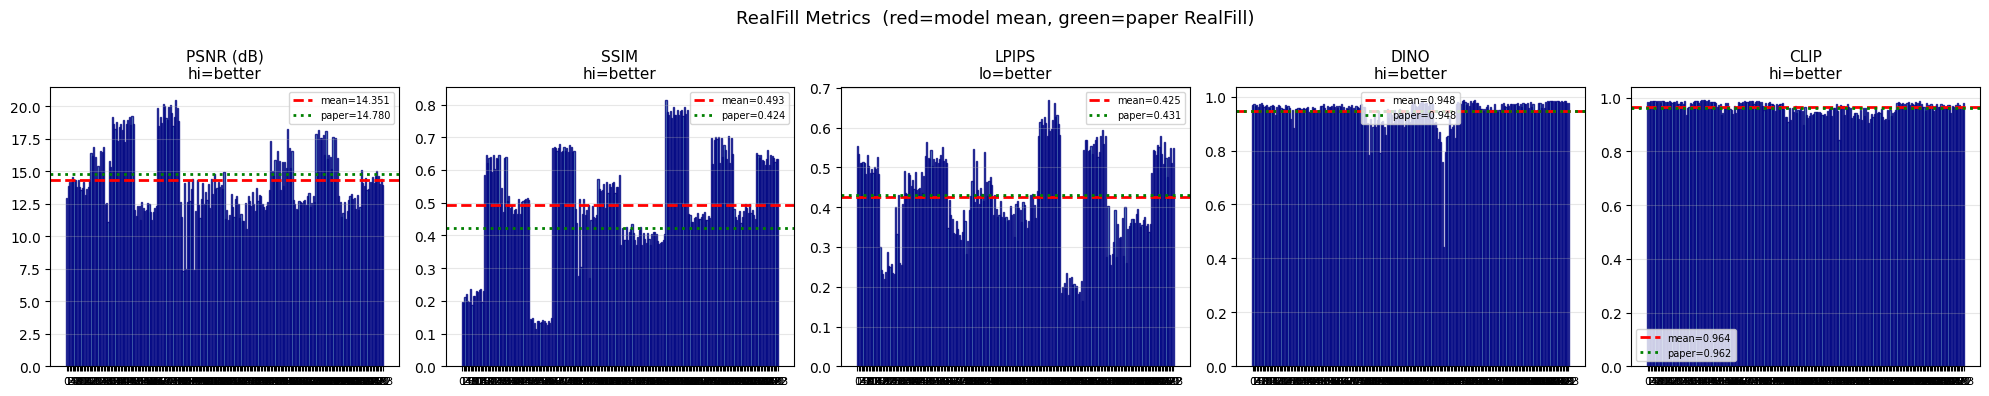

In [10]:
# Bar charts for each metric
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metric_cfg = [
    ('psnr',            'PSNR (dB)\nhi=better'),
    ('ssim',            'SSIM\nhi=better'),
    ('lpips',           'LPIPS\nlo=better'),
    ('dino_cosine_sim', 'DINO\nhi=better'),
    ('clip_cosine_sim', 'CLIP\nhi=better'),
]
paper_vals = {'psnr':14.78,'ssim':0.424,'lpips':0.431,'dino_cosine_sim':0.948,'clip_cosine_sim':0.962}
for ax, (key, label) in zip(axes, metric_cfg):
    if key not in df.columns: continue
    vals = df[key].values
    x = np.arange(len(vals))
    ax.bar(x, vals, color='steelblue', edgecolor='navy', alpha=0.8)
    ax.axhline(y=vals.mean(), color='red', ls='--', lw=2, label=f'mean={vals.mean():.3f}')
    if key in paper_vals:
        ax.axhline(y=paper_vals[key], color='green', ls=':', lw=2, label=f'paper={paper_vals[key]:.3f}')
    ax.set_title(label, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in range(len(vals))], fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('RealFill Metrics  (red=model mean, green=paper RealFill)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/metrics_chart.png', dpi=150, bbox_inches='tight')
plt.show()


---

## How to Use

### Batch Evaluation Workflow
This notebook is now configured for **offline batch evaluation**. It does not generate images, but evaluates already generated images against their Ground Truths.

1. Set `EVAL_BASE_DIR` in the Configuration step to your main evaluation folder.
2. Inside `EVAL_BASE_DIR`, place each scene in its own subfolder.
3. Each subfolder **must** contain:
   * `target.png`: The input image with the missing region.
   * `mask.png`: The mask indicating the missing region (white = missing).
   * `gt.png` (or `ref.png`): The Ground Truth image to compare against.
   * `0.png`, `1.png`, ..., `15.png`: The generated completions.
4. Run all cells sequentially. The notebook will process all subfolders and compute the average metrics.

### Metrics Reference
| Metric | Level | Region | Direction |
|--------|-------|--------|----------|
| PSNR | Low | Filled area | higher=better |
| SSIM | Low | Filled area | higher=better |
| LPIPS | Low | Filled area | lower=better |
| DreamSim | Mid | Full image | lower=better |
| CLIP | High | Full image | higher=better |
| DINO | High | Full image | higher=better |